In [1]:
# Cell 1 — Setup
from pathlib import Path
import json
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

SEED = 42
np.random.seed(SEED)

PROJECT_ROOT = Path("/teamspace/studios/this_studio/accessops_coco_ai")
CSV_PATH = PROJECT_ROOT / "artifacts" / "captions_clean_with_splits.csv"

EDA_DIR = PROJECT_ROOT / "artifacts" / "stage1b_eda"
FIG_DIR = EDA_DIR / "figures"
TAB_DIR = EDA_DIR / "tables"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("ggplot")

print("CSV exists:", CSV_PATH.exists())
print("EDA_DIR:", EDA_DIR)

CSV exists: True
EDA_DIR: /teamspace/studios/this_studio/accessops_coco_ai/artifacts/stage1b_eda


In [2]:
# Cell 2 — Load data
df = pd.read_csv(CSV_PATH)

# enforce expected dtypes/format
df["image_name"] = df["image_name"].astype(str)
df["comment_clean"] = df["comment_clean"].astype(str).str.strip().str.lower()
df["split"] = df["split"].astype(str)

# remove accidental empties
df = df[df["comment_clean"].str.len() > 0].reset_index(drop=True)

# caption length feature
df["cap_len_words"] = df["comment_clean"].str.split().str.len()

print("Rows:", len(df))
print("Columns:", list(df.columns))
print(df["split"].value_counts())


Rows: 616767
Columns: ['image_name', 'image_path', 'comment_number', 'comment', 'comment_clean', 'split', 'cap_len_words']
split
train    591753
val       12508
test      12506
Name: count, dtype: int64


In [3]:
# Cell 3 — Core summary tables
rows_by_split = df["split"].value_counts().rename_axis("split").reset_index(name="rows")
unique_images_by_split = (
    df.groupby("split")["image_name"].nunique().rename("unique_images").reset_index()
)
cap_len_stats = (
    df.groupby("split")["cap_len_words"]
      .agg(["count", "min", "max", "mean", "median"])
      .reset_index()
)

rows_by_split.to_csv(TAB_DIR / "rows_by_split.csv", index=False)
unique_images_by_split.to_csv(TAB_DIR / "unique_images_by_split.csv", index=False)
cap_len_stats.to_csv(TAB_DIR / "caption_length_stats_by_split.csv", index=False)

display(rows_by_split)
display(unique_images_by_split)
display(cap_len_stats)


,split,rows
0,train,591753
1,val,12508
2,test,12506


,split,unique_images
0,test,2500
1,train,118287
2,val,2500


,split,count,min,max,mean,median
0,test,12506,7,49,10.417640,10.0
1,train,591753,5,49,10.454947,10.0
2,val,12508,7,34,10.457867,10.0


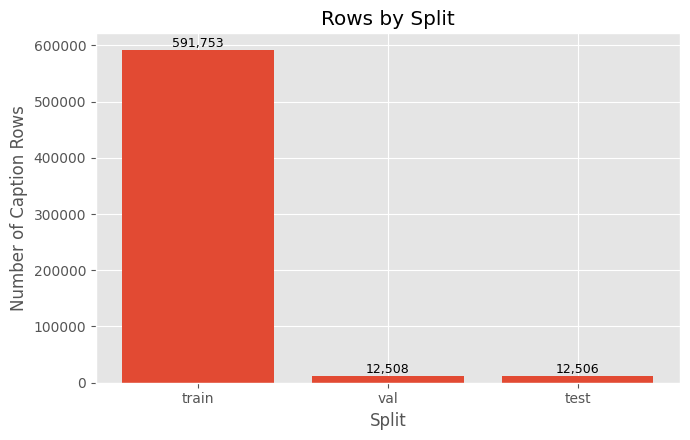

In [4]:
# Cell 4 — Chart 1: Rows by split
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(rows_by_split["split"], rows_by_split["rows"])
ax.set_title("Rows by Split")
ax.set_xlabel("Split")
ax.set_ylabel("Number of Caption Rows")
for i, v in enumerate(rows_by_split["rows"]):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "01_rows_by_split.png", dpi=180)
plt.show()


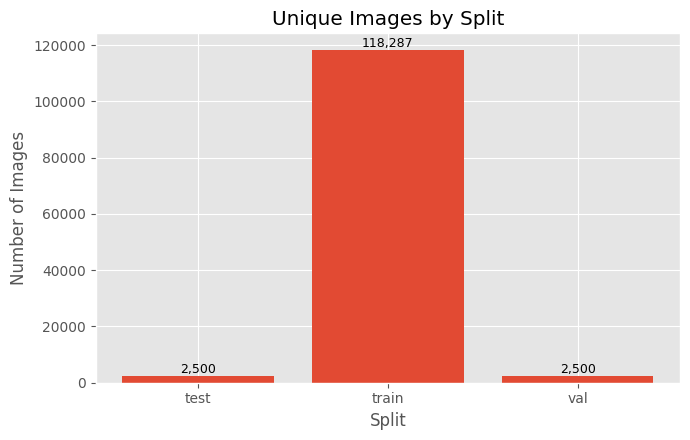

In [14]:
# Cell 5 — Chart 2: Unique images by split
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(unique_images_by_split["split"], unique_images_by_split["unique_images"])
ax.set_title("Unique Images by Split")
ax.set_xlabel("Split")
ax.set_ylabel("Number of Images")
for i, v in enumerate(unique_images_by_split["unique_images"]):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "02_unique_images_by_split.png", dpi=180)
plt.show()


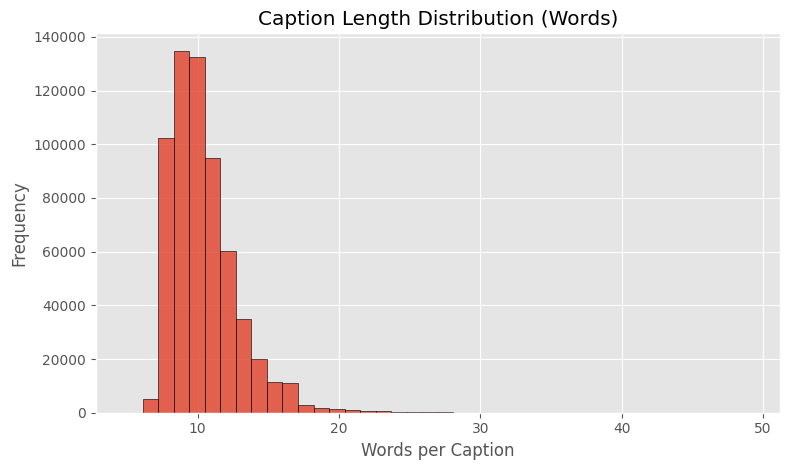

In [5]:
# Cell 6 — Chart 3: Caption length distribution (all data)
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.hist(df["cap_len_words"], bins=40, edgecolor="black", alpha=0.85)
ax.set_title("Caption Length Distribution (Words)")
ax.set_xlabel("Words per Caption")
ax.set_ylabel("Frequency")
fig.tight_layout()
fig.savefig(FIG_DIR / "03_caption_length_histogram.png", dpi=180)
plt.show()


/tmp/ipykernel_150500/2946263360.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_for_box, labels=order, showfliers=False)


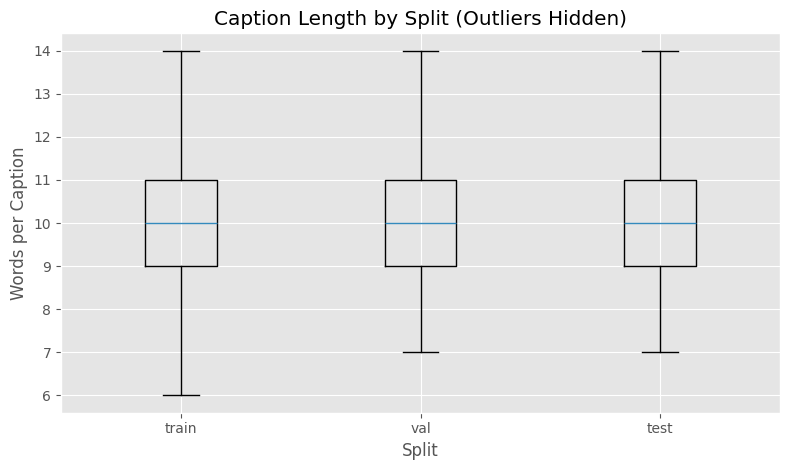

In [15]:
# Cell 7 — Chart 4: Caption length by split (boxplot)
order = ["train", "val", "test"]
data_for_box = [df.loc[df["split"] == s, "cap_len_words"].values for s in order]

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.boxplot(data_for_box, labels=order, showfliers=False)
ax.set_title("Caption Length by Split (Outliers Hidden)")
ax.set_xlabel("Split")
ax.set_ylabel("Words per Caption")
fig.tight_layout()
fig.savefig(FIG_DIR / "04_caption_length_boxplot_by_split.png", dpi=180)
plt.show()


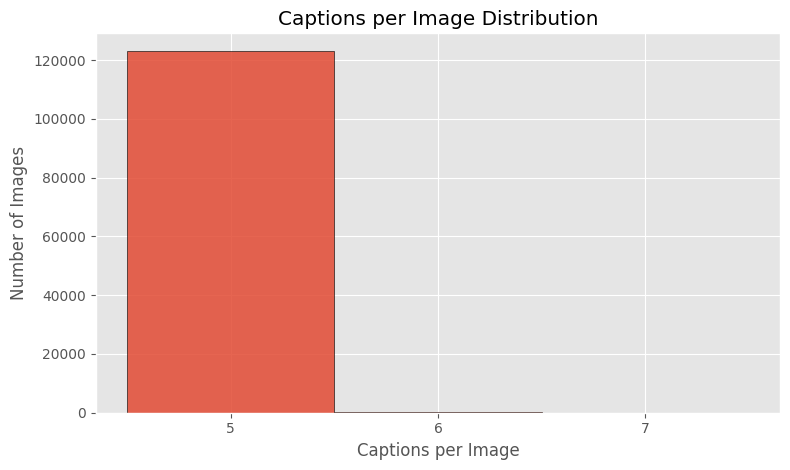

In [6]:
# Cell 8 — Chart 5: Captions-per-image distribution
caps_per_image = (
    df.groupby(["split", "image_name"]).size().rename("captions_per_image").reset_index()
)
caps_per_image.to_csv(TAB_DIR / "captions_per_image_by_split.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 4.8))
vals = caps_per_image["captions_per_image"].values
bins = np.arange(vals.min(), vals.max() + 2) - 0.5
ax.hist(vals, bins=bins, edgecolor="black", alpha=0.85)
ax.set_title("Captions per Image Distribution")
ax.set_xlabel("Captions per Image")
ax.set_ylabel("Number of Images")
ax.set_xticks(sorted(caps_per_image["captions_per_image"].unique()))
fig.tight_layout()
fig.savefig(FIG_DIR / "05_captions_per_image_histogram.png", dpi=180)
plt.show()


In [7]:
# Cell 9 — Word and bigram frequencies
word_counter = Counter()
bigram_counter = Counter()

for cap in tqdm(df["comment_clean"], total=len(df), desc="Counting n-grams"):
    toks = cap.split()
    word_counter.update(toks)
    if len(toks) > 1:
        bigram_counter.update(zip(toks[:-1], toks[1:]))

top30_words = pd.DataFrame(word_counter.most_common(30), columns=["word", "count"])
top20_bigrams = pd.DataFrame(
    [(" ".join(bg), c) for bg, c in bigram_counter.most_common(20)],
    columns=["bigram", "count"]
)

top30_words.to_csv(TAB_DIR / "top30_words.csv", index=False)
top20_bigrams.to_csv(TAB_DIR / "top20_bigrams.csv", index=False)

display(top30_words.head(10))
display(top20_bigrams.head(10))


Counting n-grams:   0%|          | 0/616767 [00:00<?, ?it/s]

,word,count
0,a,1019751
1,on,224731
2,of,212678
3,the,206174
4,in,191657
5,with,161207
6,and,146580
7,is,102389
8,man,75939
9,to,71162


,bigram,count
0,on a,109546
1,in a,70460
2,of a,69307
3,with a,62368
4,a man,60839
5,in the,53182
6,on the,45968
7,next to,38487
8,and a,32232
9,sitting on,27925


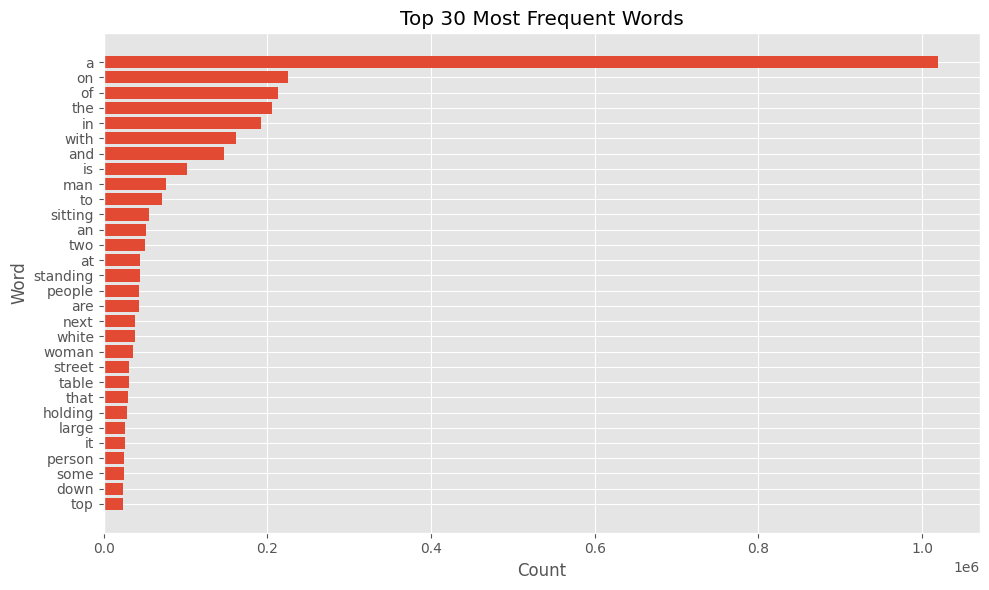

In [8]:
# Cell 10 — Chart 6: Top 30 words
fig, ax = plt.subplots(figsize=(10, 6))
top30_words_plot = top30_words.sort_values("count", ascending=True)
ax.barh(top30_words_plot["word"], top30_words_plot["count"])
ax.set_title("Top 30 Most Frequent Words")
ax.set_xlabel("Count")
ax.set_ylabel("Word")
fig.tight_layout()
fig.savefig(FIG_DIR / "06_top30_words.png", dpi=180)
plt.show()


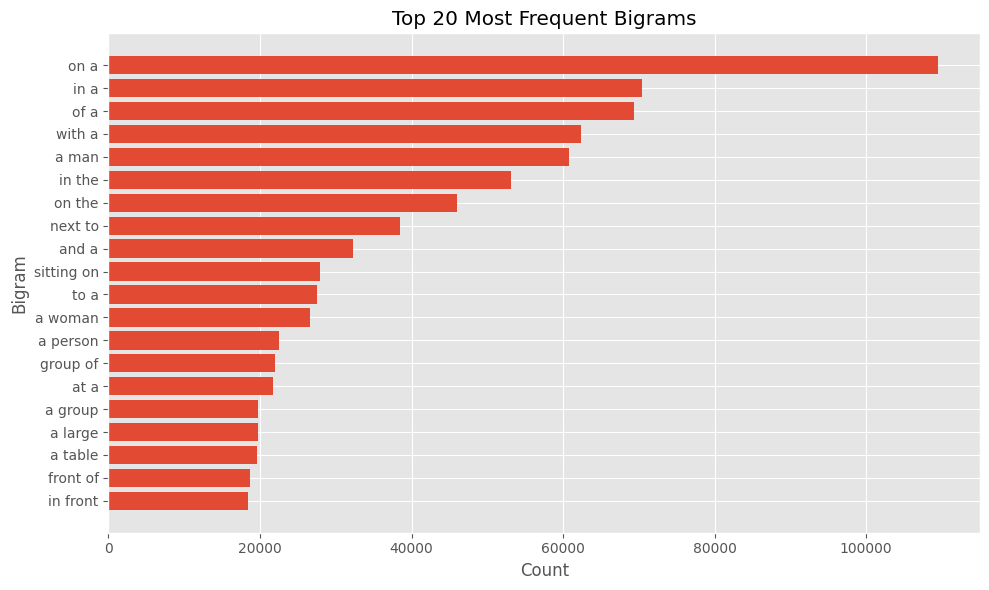

In [16]:
# Cell 11 — Chart 7: Top 20 bigrams
fig, ax = plt.subplots(figsize=(10, 6))
top20_bigrams_plot = top20_bigrams.sort_values("count", ascending=True)
ax.barh(top20_bigrams_plot["bigram"], top20_bigrams_plot["count"])
ax.set_title("Top 20 Most Frequent Bigrams")
ax.set_xlabel("Count")
ax.set_ylabel("Bigram")
fig.tight_layout()
fig.savefig(FIG_DIR / "07_top20_bigrams.png", dpi=180)
plt.show()


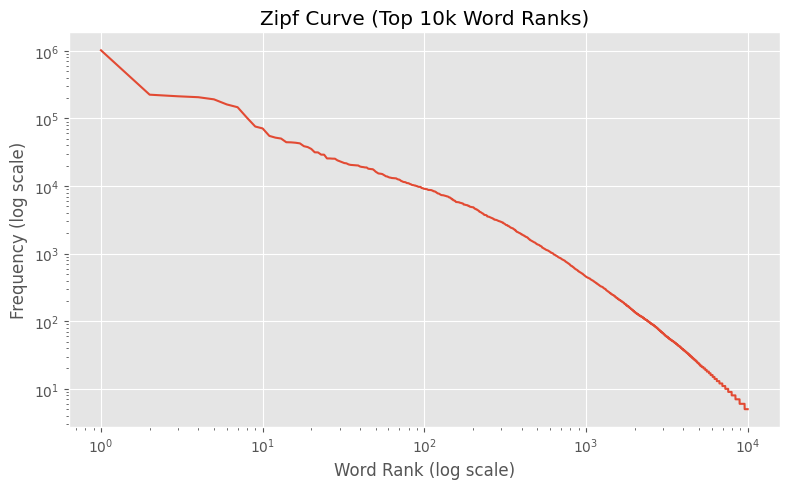

In [9]:
# Cell 12 — Chart 8: Zipf-like curve (word rank vs frequency)
freqs = np.array(sorted(word_counter.values(), reverse=True))
ranks = np.arange(1, len(freqs) + 1)

# plot top 10k for readability
k = min(10000, len(freqs))
fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(ranks[:k], freqs[:k])
ax.set_title("Zipf Curve (Top 10k Word Ranks)")
ax.set_xlabel("Word Rank (log scale)")
ax.set_ylabel("Frequency (log scale)")
fig.tight_layout()
fig.savefig(FIG_DIR / "08_zipf_curve.png", dpi=180)
plt.show()


In [10]:
# Cell 13 — Duplicate analysis + sample table
exact_dup_same_image = int(df.duplicated(subset=["image_name", "comment_clean"]).sum())
global_dup_caption_text = int(df.duplicated(subset=["comment_clean"]).sum())

dup_stats = pd.DataFrame([{
    "exact_duplicate_within_same_image": exact_dup_same_image,
    "duplicate_caption_text_global": global_dup_caption_text
}])
dup_stats.to_csv(TAB_DIR / "duplicate_stats.csv", index=False)

sample_rows = df.sample(25, random_state=SEED)[
    ["split", "image_name", "comment_number", "comment_clean", "cap_len_words"]
].sort_values(["split", "image_name"])
sample_rows.to_csv(TAB_DIR / "sample_rows.csv", index=False)

display(dup_stats)
display(sample_rows.head(10))


,exact_duplicate_within_same_image,duplicate_caption_text_global
0,323,27150


,split,image_name,comment_number,comment_clean,cap_len_words
205284,train,000000032533.jpg,3,a man watches traffic before taking off on his...,10
177192,train,000000044677.jpg,3,a man setting at a table in a restaurant cutti...,12
234303,train,000000062893.jpg,2,a little boy sitting on a rug watching tv,9
282114,train,000000095892.jpg,5,there is a sheep with a mutated set of horns,10
467057,train,000000097722.jpg,2,skiers stand in the snow outside a ski lodge w...,13
215870,train,000000125168.jpg,5,a brick mexican restaurant a street sign and s...,10
171916,train,000000132652.jpg,3,a woman is smiling and talking on a cellphone,9
236392,train,000000141920.jpg,5,a man sits on a toilet and reads a comic,10
450144,train,000000145189.jpg,2,a man who is holding two hot dogs in his hand,11
158910,train,000000153283.jpg,5,a ferris wheel is visible behind the buildings...,10


FIG_DIR: /teamspace/studios/this_studio/accessops_coco_ai/artifacts/stage1b_eda/figures
TAB_DIR: /teamspace/studios/this_studio/accessops_coco_ai/artifacts/stage1b_eda/tables


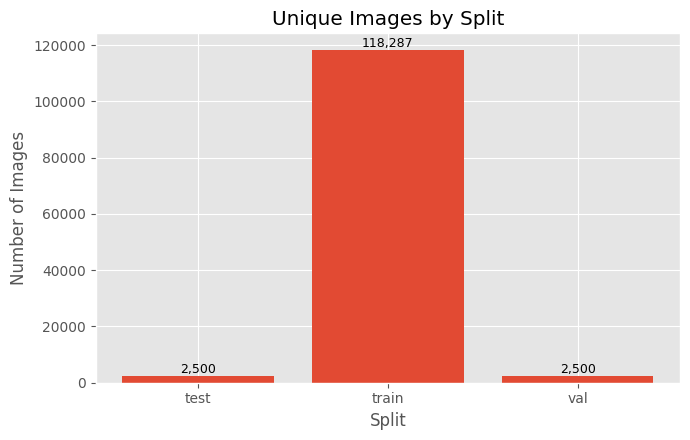

Saved: /teamspace/studios/this_studio/accessops_coco_ai/artifacts/stage1b_eda/figures/02_unique_images_by_split.png
Current PNG files: ['02_unique_images_by_split.png', '01_rows_by_split.png', '05_captions_per_image_histogram.png', '08_zipf_curve.png', '03_caption_length_histogram.png', '06_top30_words.png']


In [12]:
# Recovery: regenerate missing figure 02_unique_images_by_split.png
import pandas as pd
import matplotlib.pyplot as plt

print("FIG_DIR:", FIG_DIR)
print("TAB_DIR:", TAB_DIR)

u = pd.read_csv(TAB_DIR / "unique_images_by_split.csv")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(u["split"], u["unique_images"])
ax.set_title("Unique Images by Split")
ax.set_xlabel("Split")
ax.set_ylabel("Number of Images")
for i, v in enumerate(u["unique_images"]):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "02_unique_images_by_split.png", dpi=180)
plt.show()

print("Saved:", FIG_DIR / "02_unique_images_by_split.png")
print("Current PNG files:", [p.name for p in FIG_DIR.glob("*.png")])


In [17]:
# Cell 14 — Save EDA summary JSON + gate check
summary = {
    "rows_total": int(len(df)),
    "rows_by_split": {k: int(v) for k, v in df["split"].value_counts().to_dict().items()},
    "unique_images_by_split": {
        k: int(v) for k, v in df.groupby("split")["image_name"].nunique().to_dict().items()
    },
    "caption_len": {
        "min": int(df["cap_len_words"].min()),
        "max": int(df["cap_len_words"].max()),
        "mean": float(df["cap_len_words"].mean()),
        "median": float(df["cap_len_words"].median()),
        "p95": float(df["cap_len_words"].quantile(0.95))
    },
    "vocab_size_observed": int(len(word_counter)),
    "exact_duplicate_within_same_image": exact_dup_same_image,
    "duplicate_caption_text_global": global_dup_caption_text
}

(EDA_DIR / "eda_summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")

required_files = [
    EDA_DIR / "eda_summary.json",
    FIG_DIR / "01_rows_by_split.png",
    FIG_DIR / "02_unique_images_by_split.png",
    FIG_DIR / "03_caption_length_histogram.png",
    FIG_DIR / "04_caption_length_boxplot_by_split.png",
    FIG_DIR / "05_captions_per_image_histogram.png",
    FIG_DIR / "06_top30_words.png",
    FIG_DIR / "07_top20_bigrams.png",
    FIG_DIR / "08_zipf_curve.png",
    TAB_DIR / "rows_by_split.csv",
    TAB_DIR / "unique_images_by_split.csv",
    TAB_DIR / "caption_length_stats_by_split.csv",
    TAB_DIR / "captions_per_image_by_split.csv",
    TAB_DIR / "top30_words.csv",
    TAB_DIR / "top20_bigrams.csv",
    TAB_DIR / "duplicate_stats.csv",
    TAB_DIR / "sample_rows.csv",
]
for p in required_files:
    assert p.exists(), f"Missing: {p}"

print("STAGE 1B PASS")
print("Saved summary:", EDA_DIR / "eda_summary.json")


STAGE 1B PASS
Saved summary: /teamspace/studios/this_studio/accessops_coco_ai/artifacts/stage1b_eda/eda_summary.json
